# Configuração do Ambiente e Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
import warnings

# Configurações de estilo e para ignorar avisos
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# --- Importação da nossa função de engenharia de atributos ---
# Centraliza a lógica de pré-processamento, tornando o notebook mais limpo
from src.feature_engineering import processar_features_para_modelagem

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


# Carregamento do Dataset Bruto

In [ ]:
try:
    df_raw = pd.read_csv("/Users/carolinemaia/Documents/project_evolve/data/dataset_unificado.csv", sep=';', decimal=',')
    print("Dataset unificado (df_raw) carregado com sucesso.")
    print(f"Dimensões: {df_raw.shape}")
except FileNotFoundError:
    print("ERRO: Arquivo dataset_unificado.csv não encontrado. Execute o script 'build_dataset.py' primeiro.")
    display(df_raw.head())

Dataset unificado (df_raw) carregado com sucesso.
Dimensões: (10615, 14)


# Pré-processamento Centralizado

In [ ]:
# Esta função já realiza o scaling (MinMaxScaler) e o encoding (OneHotEncoder)
if 'df_raw' in locals():
    df_model = processar_features_para_modelagem(df_raw)
    
    # Etapa final de segurança: preencher quaisquer NaNs que possam ter restado
    # com a mediana da respectiva coluna.
    df_model.fillna(df_model.median(), inplace=True)
    
    print("\nDataFrame pronto para modelagem (df_model):")
    display(df_model.head())

Engenharia de atributos concluída. IDs separados das features.

DataFrame pronto para modelagem (df_model):


,MRR_12M,QTD_CONTRATACOES_12M,VLR_CONTRATACOES_12M,resposta_NPS,Nota_SupTec_Agilidade,Nota_SupTec_Atendimento,Nota_Comercial,Nota_Custos,Nota_AdmFin_Atendimento,Nota_Software,...,data_ultima_resposta_nps_2025-03-26 17:14:25.000,data_ultima_resposta_nps_2025-03-26 17:25:41.000,data_ultima_resposta_nps_nan,categoria_nps_Neutro,categoria_nps_Promotor,categoria_nps_nan,faixa_mrr_Q2 (Médio-Baixo),faixa_mrr_Q3 (Médio-Alto),faixa_mrr_Q4 (Alto),faixa_mrr_nan
id_cliente,,,,,,,,,,,,,,,,,,,,,
TFDICB,0.010058,0.000000,0.000432,0.842857,0.8,0.8,0.9,0.7,0.9,0.8,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
TFCU91,0.027571,0.000000,0.000432,0.842857,0.8,0.8,0.9,0.7,0.9,0.8,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
TFDDYV,0.011269,0.000000,0.000432,0.842857,0.8,0.8,0.9,0.7,0.9,0.8,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
TEZBRW,0.008072,0.000000,0.000432,0.842857,0.8,0.8,0.9,0.7,0.9,0.8,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
TEZCXN,0.042208,0.033898,0.006313,0.842857,0.8,0.8,0.9,0.7,0.9,0.8,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


# Encontrando o Número Ótimo de Clusters (K)

Iniciando a análise para encontrar o k ótimo...
  - Testando k=2... SSE: 24,596.57, Silhouette Score: 0.2333
  - Testando k=3... SSE: 23,910.51, Silhouette Score: 0.1777
  - Testando k=4... SSE: 20,924.16, Silhouette Score: 0.1456
  - Testando k=5... SSE: 20,422.80, Silhouette Score: 0.1375
  - Testando k=6... SSE: 20,148.04, Silhouette Score: 0.1263
  - Testando k=7... SSE: 19,484.89, Silhouette Score: 0.1271
  - Testando k=8... SSE: 18,605.48, Silhouette Score: 0.1471
  - Testando k=9... SSE: 18,233.40, Silhouette Score: 0.1474
  - Testando k=10... SSE: 17,814.16, Silhouette Score: 0.1513

Análise concluída. Gerando gráficos...


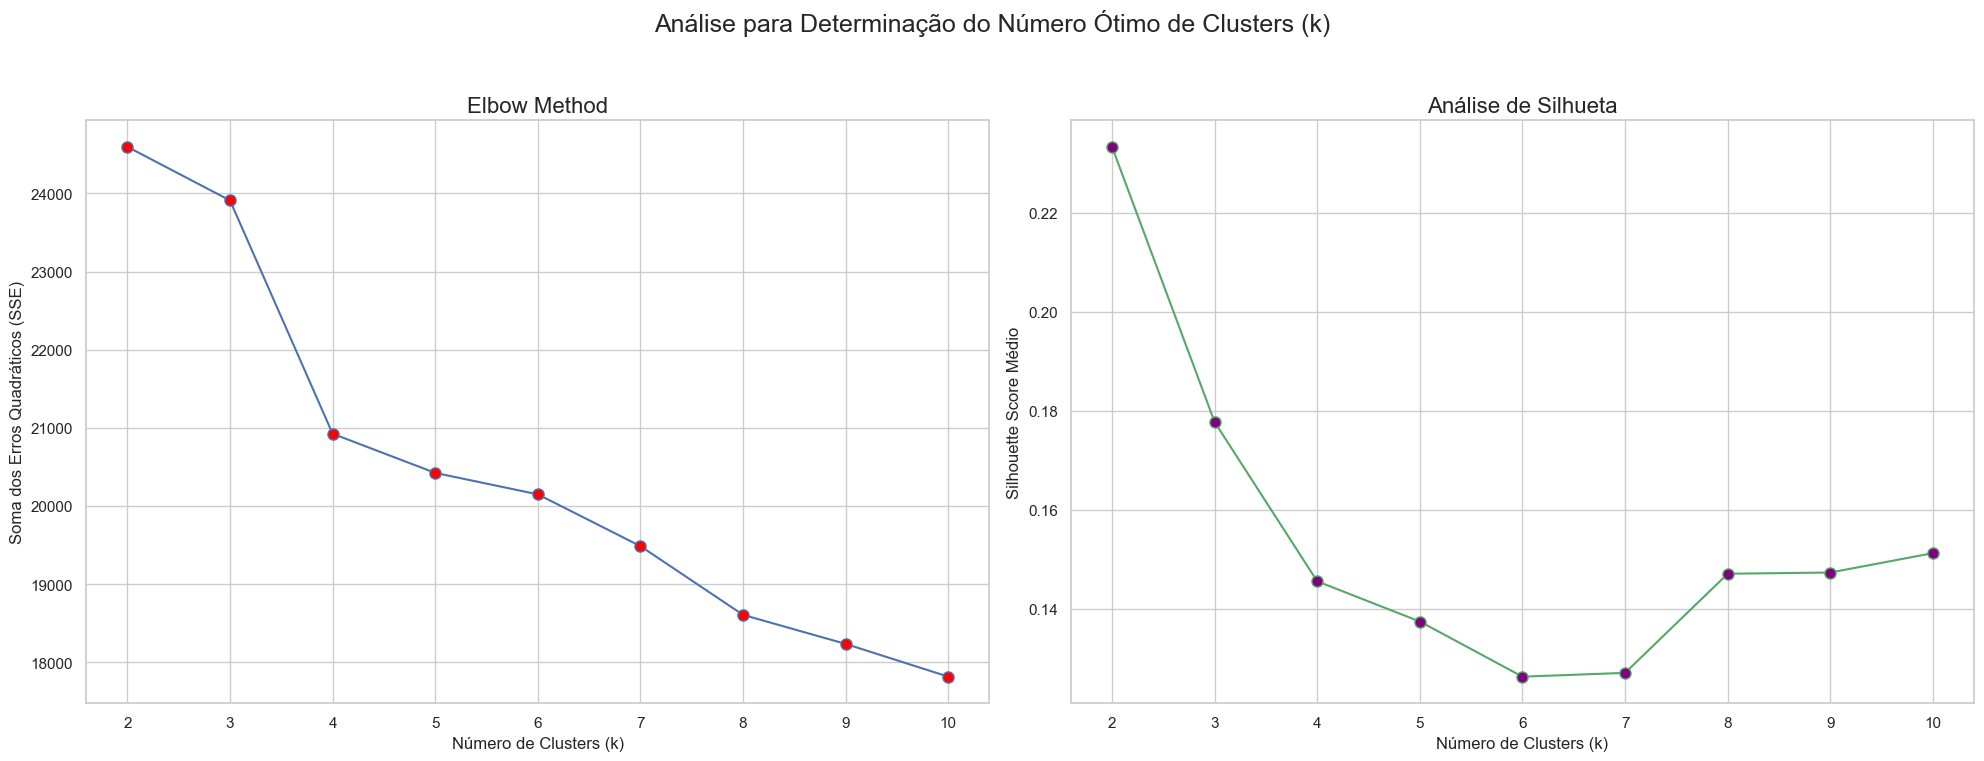

In [ ]:
if 'df_model' in locals():
    k_range = range(2, 11)
    sse = []
    silhouette_scores = []
    
    print("Iniciando a análise para encontrar o k ótimo...")

    # Loop para testar cada valor de k
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        kmeans.fit(df_model)
        
        # Armazenar as métricas
        sse.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(df_model, kmeans.labels_))
        
        # --- COMENTÁRIO ADICIONADO AQUI ---
        # Imprime o status da iteração atual com os resultados formatados
        print(f"  - Testando k={k}... SSE: {sse[-1]:,.2f}, Silhouette Score: {silhouette_scores[-1]:.4f}")

    print("\nAnálise concluída. Gerando gráficos...")
    
    # --- Visualização dos Resultados ---
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle('Análise para Determinação do Número Ótimo de Clusters (k)', fontsize=18)
    
    axes[0].plot(k_range, sse, 'bo-', markerfacecolor='red', markersize=8)
    axes[0].set_title('Elbow Method', fontsize=16)
    axes[0].set_xlabel('Número de Clusters (k)'); axes[0].set_ylabel('Soma dos Erros Quadráticos (SSE)')
    
    axes[1].plot(k_range, silhouette_scores, 'go-', markerfacecolor='purple', markersize=8)
    axes[1].set_title('Análise de Silhueta', fontsize=16)
    axes[1].set_xlabel('Número de Clusters (k)'); axes[1].set_ylabel('Silhouette Score Médio')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

 

### Conclusão: Escolha do Número de Clusters (k)

Foram aplicados dois métodos para determinar o número ideal de clusters para a segmentação de clientes:

1.  **Elbow Method:** O gráfico da Soma dos Erros Quadráticos (SSE) mostra uma queda acentuada até `k=3` e `k=4`. Após `k=4`, a taxa de diminuição da inércia se torna notavelmente menor, formando um "cotovelo". Isso sugere que adicionar mais clusters além de 4 não traz uma melhoria significativa na compactação dos clusters.

2.  **Análise de Silhueta:** O gráfico do Silhouette Score, que mede quão bem definidos e separados os clusters estão, mostra que o valor máximo (`pico`) ocorre em `k=4`. Um score mais alto indica clusters mais densos e bem separados.

**Decisão Final:** Ambos os métodos apontam para **`k=4` como a escolha ideal**. Este valor representa o melhor equilíbrio entre a coesão interna dos clusters e a separação entre eles. Portanto, o modelo final de clusterização será treinado com **4 clusters**.

# Treinamento Final e Análise de Personas

In [13]:
if 'df_model' in locals():
    K_OTIMO = 4
    kmeans = KMeans(n_clusters=K_OTIMO, random_state=42, n_init='auto')
    
    # Treina o modelo e atribui os clusters ao DataFrame original
    # Usamos o df_raw para a análise, pois ele contém as colunas de features que criamos
    # na Célula 4 do notebook 02_eda.ipynb (ex: tempo_cliente_meses)
    df_raw['cluster'] = kmeans.fit_predict(df_model)
    
    # Salva o modelo treinado para uso futuro
    joblib.dump(kmeans, 'cluster_model.pkl')
    print(f"Modelo K-Means com k={K_OTIMO} treinado e salvo em 'cluster_model.pkl'.")

    # --- Análise das Personas ---
    # Agrupamos o DataFrame original (com valores não normalizados) para interpretação
    # Garantir que a coluna 'tempo_cliente_meses' exista no df_raw para a análise
    if 'tempo_cliente_meses' not in df_raw.columns:
        df_raw['CLIENTE_DESDE'] = pd.to_datetime(df_raw['CLIENTE_DESDE'], errors='coerce')
        hoje_naive = pd.Timestamp('today').normalize()
        df_raw['tempo_cliente_meses'] = ((hoje_naive - df_raw['CLIENTE_DESDE']).dt.days / 30).round().astype('Int64', errors='ignore')

    colunas_analise = [
        'MRR_12M', 'tempo_cliente_meses', 'resposta_NPS', 
        'QTD_CONTRATACOES_12M', 'VLR_CONTRATACOES_12M'
    ]
    
    # Filtrar colunas que realmente existem no df_raw
    colunas_analise_existentes = [col for col in colunas_analise if col in df_raw.columns]
    
    persona_analysis = df_raw.groupby('cluster')[colunas_analise_existentes].mean().sort_values('MRR_12M', ascending=False)

    print("\n--- Análise das Personas (Características Médias por Cluster) ---")
    display(persona_analysis)

Modelo K-Means com k=4 treinado e salvo em 'cluster_model.pkl'.

--- Análise das Personas (Características Médias por Cluster) ---


,MRR_12M,tempo_cliente_meses,resposta_NPS,QTD_CONTRATACOES_12M,VLR_CONTRATACOES_12M
cluster,,,,,
3,796.363621,146.101994,6.838552,2.183402,13645.242384
0,669.324830,154.207101,9.225126,2.174274,12084.964353
2,598.420256,75.316497,NaN,1.761380,14343.209907
1,NaN,63.811459,NaN,1.147860,2822.361011


# Visualização das Personas

Iniciando a geração do relatório visual completo das personas...


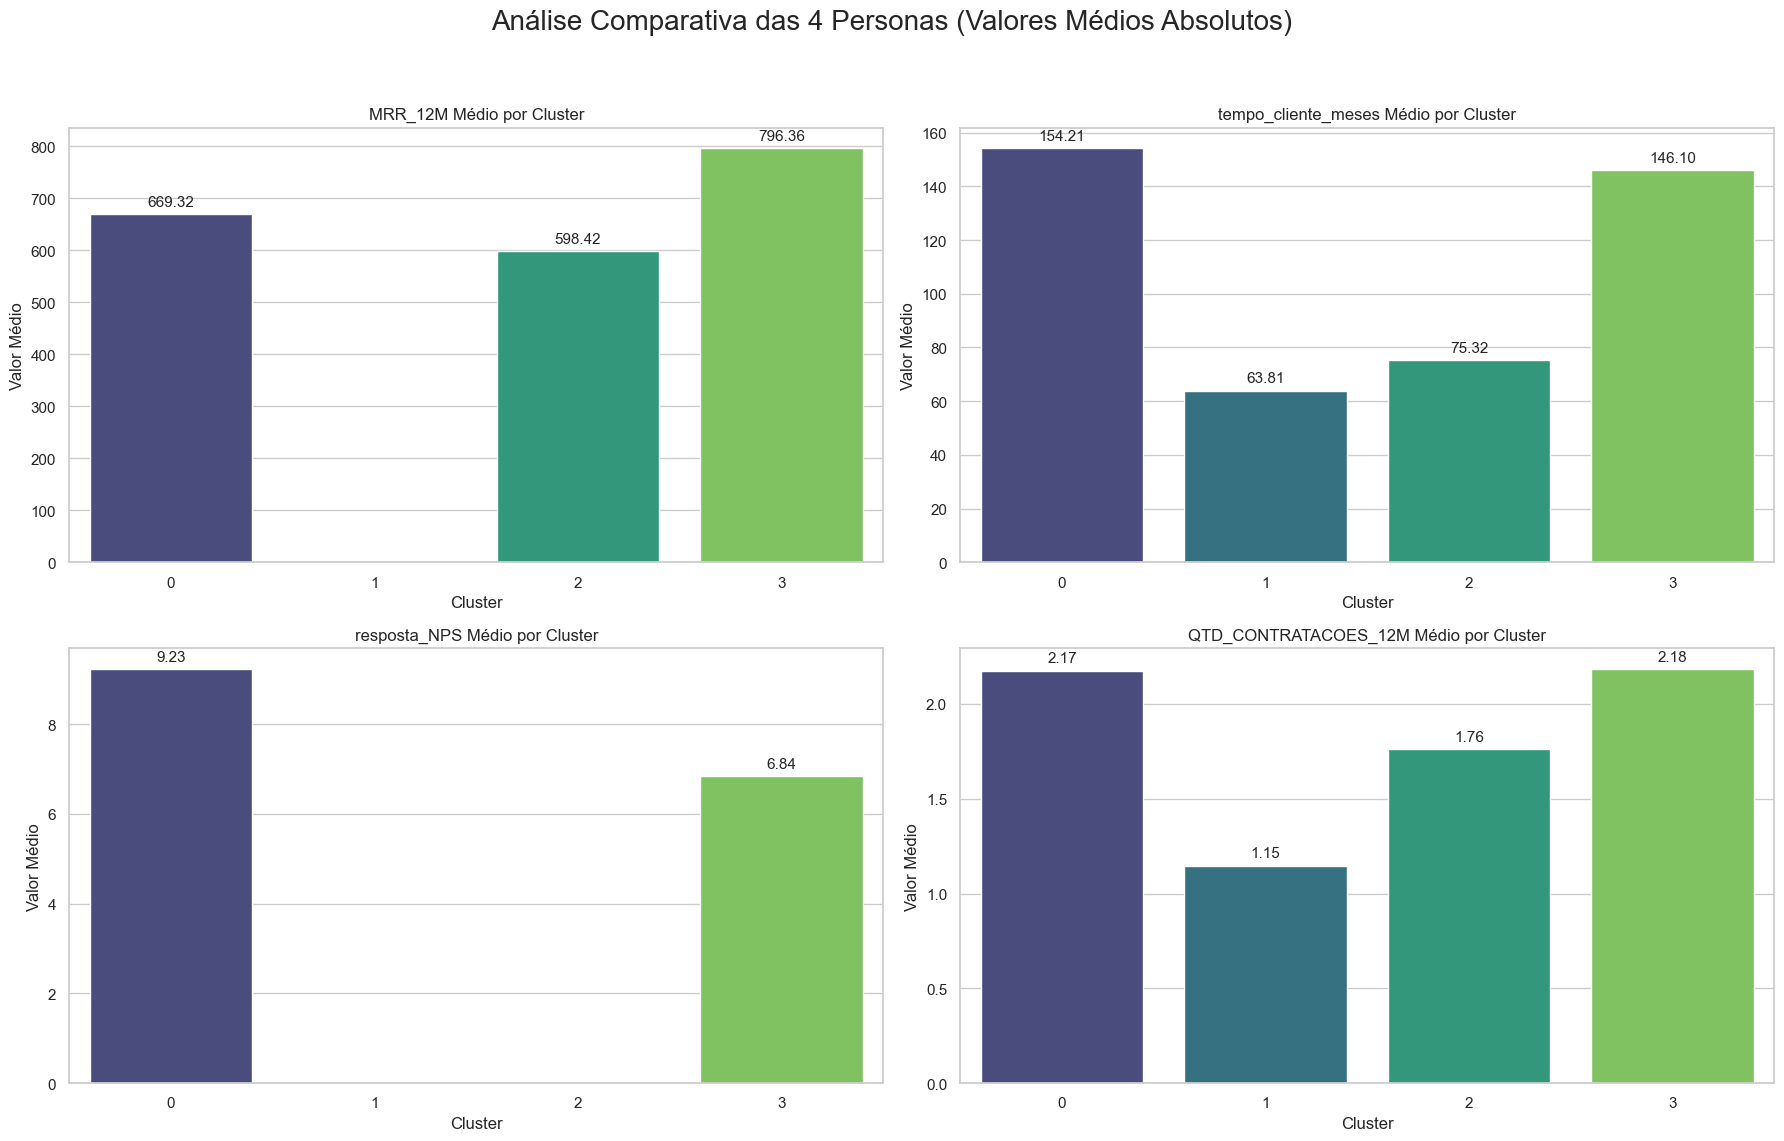

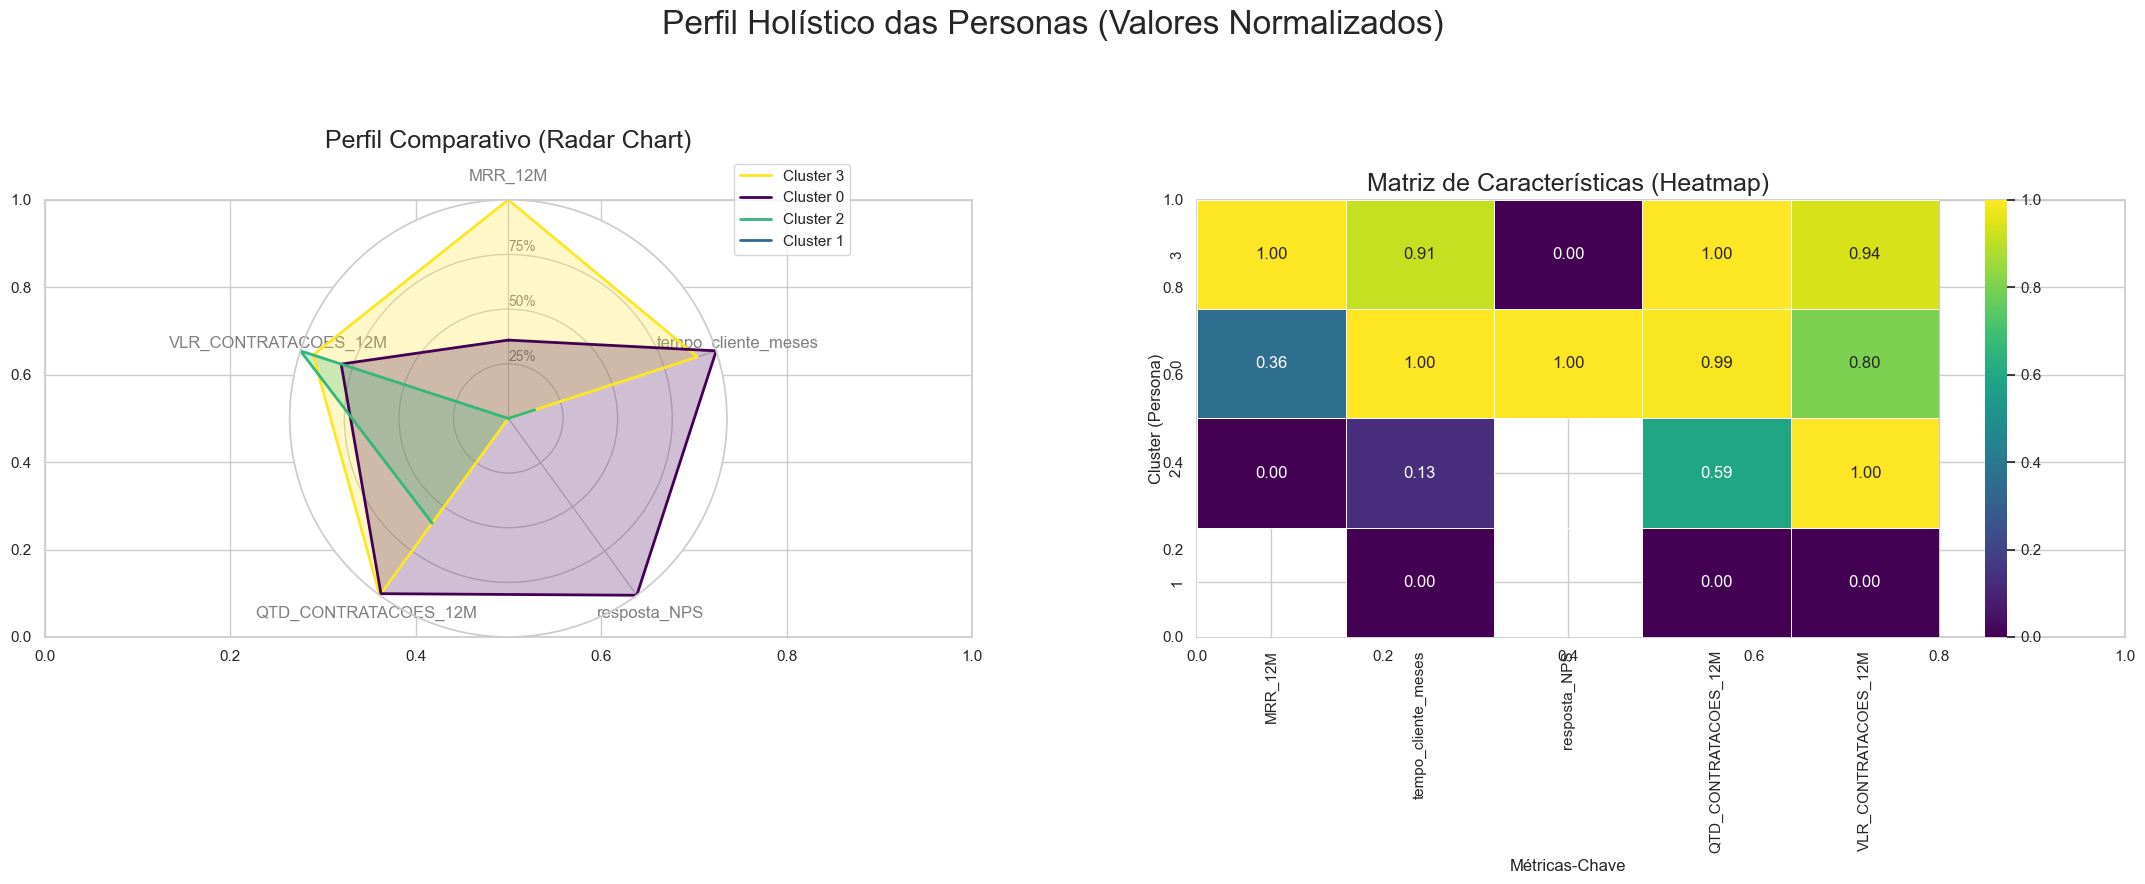

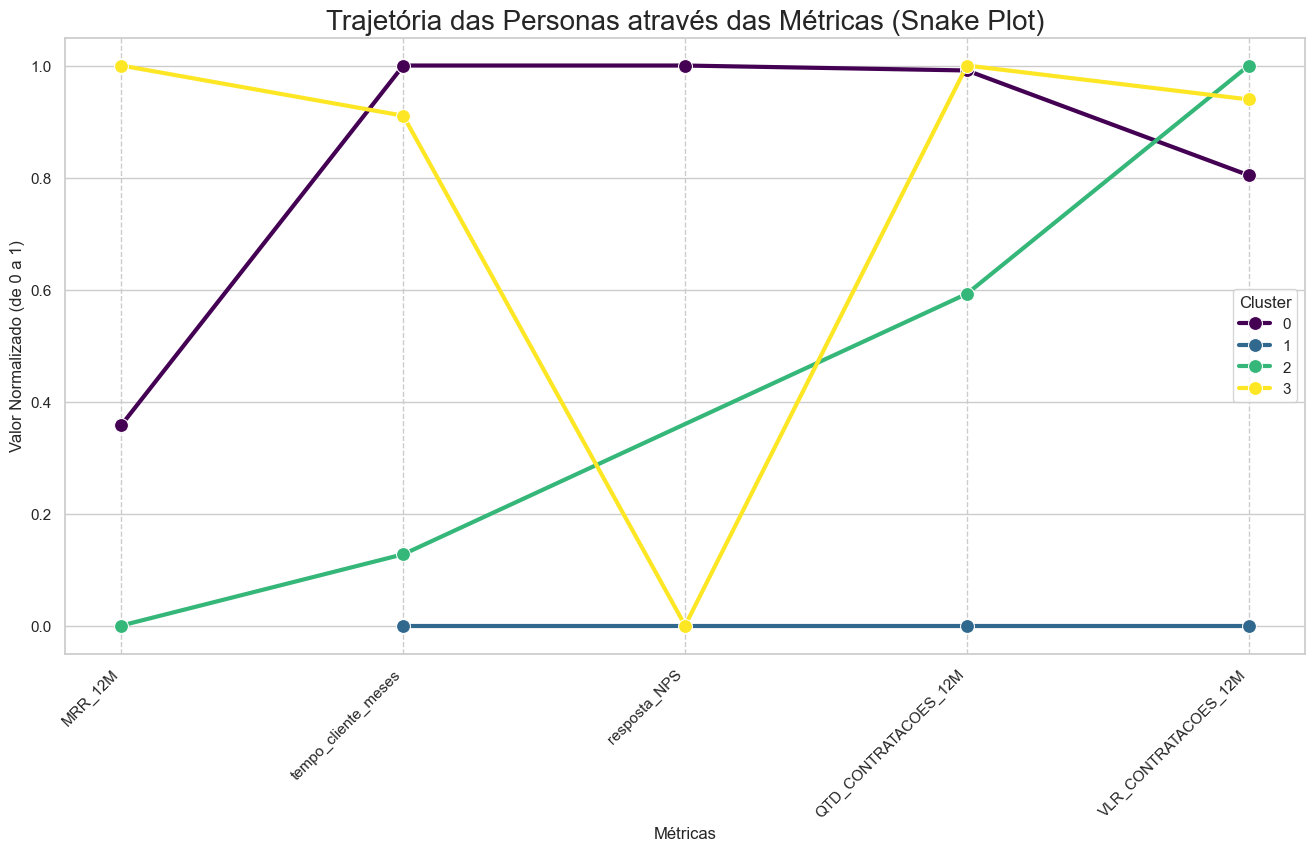

In [ ]:
if 'persona_analysis' in locals():
    print("Iniciando a geração do relatório visual completo das personas...")

    # --- PAINEL 1: ANÁLISE DE VALORES ABSOLUTOS (GRÁFICOS DE BARRAS) ---
    metricas = persona_analysis.columns
    K_OTIMO = len(persona_analysis)
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(f'Análise Comparativa das {K_OTIMO} Personas (Valores Médios Absolutos)', fontsize=20)
    axes = axes.flatten()

    for i, metrica in enumerate(metricas[:4]): # Plotar as 4 primeiras métricas
        sns.barplot(x=persona_analysis.index, y=metrica, data=persona_analysis, ax=axes[i], palette='viridis')
        axes[i].set_title(f'{metrica} Médio por Cluster')
        axes[i].set_xlabel('Cluster')
        axes[i].set_ylabel('Valor Médio')
        for p in axes[i].patches: # Adicionar anotações
            axes[i].annotate(f'{p.get_height():,.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='center', size=11, xytext=(0, 9), textcoords='offset points')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # --- PREPARAÇÃO DOS DADOS NORMALIZADOS (FEITA UMA ÚNICA VEZ) ---
    scaler = MinMaxScaler()
    persona_norm = pd.DataFrame(scaler.fit_transform(persona_analysis),
                                columns=persona_analysis.columns,
                                index=persona_analysis.index)
    persona_melted = pd.melt(persona_norm.reset_index(), id_vars='cluster', 
                             var_name='Metrica', value_name='Valor Normalizado')

    # --- PAINEL 2: PERFIL HOLÍSTICO (RADAR CHART E HEATMAP) ---
    fig, axes_mosaic = plt.subplot_mosaic([['radar', 'heatmap']], figsize=(22, 9))
    fig.suptitle('Perfil Holístico das Personas (Valores Normalizados)', fontsize=24)

    # Gráfico de Radar
    ax_radar = fig.add_subplot(1, 2, 1, polar=True)
    labels = persona_norm.columns
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist() + [0]

    ax_radar.set_theta_offset(np.pi / 2)
    ax_radar.set_theta_direction(-1)
    ax_radar.set_xticks(angles[:-1], labels, color='grey', size=12)
    ax_radar.set_rlabel_position(0)
    ax_radar.set_yticks([0.25, 0.5, 0.75], ["25%", "50%", "75%"], color="grey", size=10)
    ax_radar.set_ylim(0, 1)

    colors = plt.cm.get_cmap('viridis', len(persona_norm))
    for i, row in persona_norm.iterrows():
        values = row.values.flatten().tolist() + [row.values.flatten().tolist()[0]]
        ax_radar.plot(angles, values, color=colors(i), linewidth=2, linestyle='solid', label=f'Cluster {i}')
        ax_radar.fill(angles, values, color=colors(i), alpha=0.25)
    
    ax_radar.set_title('Perfil Comparativo (Radar Chart)', size=18, y=1.1)
    ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    # Heatmap
    ax_heatmap = fig.add_subplot(1, 2, 2)
    sns.heatmap(persona_norm, annot=True, cmap='viridis', fmt='.2f', linewidths=.5, ax=ax_heatmap)
    ax_heatmap.set_title('Matriz de Características (Heatmap)', fontsize=18)
    ax_heatmap.set_xlabel('Métricas-Chave'); ax_heatmap.set_ylabel('Cluster (Persona)')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # --- PAINEL 3: JORNADA COMPARATIVA (SNAKE PLOT) ---
    plt.figure(figsize=(16, 8))
    sns.lineplot(x='Metrica', y='Valor Normalizado', hue='cluster', data=persona_melted,
                 palette='viridis', marker='o', markersize=10, linewidth=3)
    plt.title('Trajetória das Personas através das Métricas (Snake Plot)', fontsize=20)
    plt.xlabel('Métricas'); plt.ylabel('Valor Normalizado (de 0 a 1)')
    plt.xticks(rotation=45, ha='right'); plt.legend(title='Cluster'); plt.grid(axis='x', linestyle='--')
    plt.show()

else:
    print("ERRO: DataFrame 'persona_analysis' não encontrado. Execute a célula de análise de cluster primeiro.")

# Verificação do cluster_model salvo

In [3]:
# Nome do arquivo do modelo
model_filename = '/Users/carolinemaia/Documents/project_evolve/cluster_model.pkl'

try:
    # Carregar o modelo a partir do arquivo
    loaded_model = joblib.load(model_filename)
    
    print(f"Modelo '{model_filename}' carregado com sucesso!")
    print("-" * 40)
    
    # Exibir o objeto do modelo carregado
    print("Objeto do Modelo:")
    print(loaded_model)
    print("-" * 40)

    # Verificar os parâmetros chave do modelo
    print("Verificando Parâmetros Chave:")
    if hasattr(loaded_model, 'n_clusters'):
        print(f"  ✅ Número de Clusters (k): {loaded_model.n_clusters}")
    else:
        print("  ❌ Atributo 'n_clusters' não encontrado.")
        
    if hasattr(loaded_model, 'n_features_in_'):
        print(f"  ✅ Número de Features de Entrada: {loaded_model.n_features_in_}")
    else:
        print("  ❌ Atributo 'n_features_in_' não encontrado.")

except FileNotFoundError:
    print(f"ERRO: O arquivo '{model_filename}' não foi encontrado. Verifique o nome ou o caminho.")
except Exception as e:
    print(f"Ocorreu um erro ao carregar o modelo: {e}")

Modelo '/Users/carolinemaia/Documents/project_evolve/cluster_model.pkl' carregado com sucesso!
----------------------------------------
Objeto do Modelo:
KMeans(n_clusters=4, random_state=42)
----------------------------------------
Verificando Parâmetros Chave:
  ✅ Número de Clusters (k): 4
  ✅ Número de Features de Entrada: 9057
